In [ ]:
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

data = pd.read_csv('../../data/openpowerlifting.csv')


data

In [ ]:
# Drop rows where any column in X or y has NaN



X_full, X_test, y_full, y_test = train_test_split(
    data[['BestBenchKg']], data[["BestDeadliftKg"]]
)

X_full["BestBenchKg"].fillna(X_full["BestBenchKg"].mean(), inplace=True)
y_full["BestDeadliftKg"].fillna(y_full["BestDeadliftKg"].mean(), inplace=True)


In [ ]:
X_train, X_valid, y_train, y_valid = train_test_split(X_full, y_full)

type(X_train)


In [ ]:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)
X_test = scaler.transform(X_test)

type(y_train)
type(X_train)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_mae",
    patience=3,
    restore_best_weights=True
)

In [ ]:
model = keras.models.Sequential([
    keras.layers.Dense(32, activation='relu',  input_shape=(X_train.shape[1],)),
    keras.layers.Dense(1)
])

model.compile(loss="mse", optimizer="SGD", metrics=['mae'])

In [ ]:
import matplotlib.pyplot as plt

history = model.fit(
    X_train, y_train,
    epochs=30,  
    validation_data=(X_valid, y_valid),
    callbacks=[early_stop])


,loss,mae,val_loss,val_mae
0,3280.014404,41.794540,3079.698975,40.838711
1,3132.912109,40.988708,3078.189697,40.624607
2,3133.063965,40.986538,3080.299805,40.910980
3,3133.203369,40.970100,3080.296631,40.881001
4,3133.188721,40.978115,3078.254395,40.656372


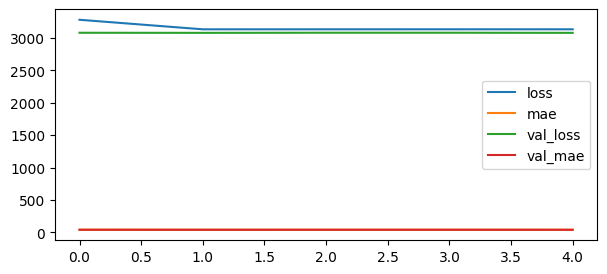

In [15]:

pd.DataFrame(history.history).plot(figsize=(7,3))
pd.DataFrame(history.history).head()


In [16]:
import numpy as np
x_new = np.array([[100]])  # shape (1,1)
model.predict(x_new)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


array([[195.07219]], dtype=float32)

KeyError: "None of [Index([1], dtype='int64')] are in the [columns]"